# Smart Robotic System for Cold Storage Monitoring
### Cognitive Robotics Project - Perception, Learning, and Action


# 1. Import Required Libraries


In [163]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r"C:\Users\HUAWEI\Downloads\Occupancy_Estimation.csv")


# 2. Load and Overview of the Dataset


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10129 non-null  object 
 1   Time                  10129 non-null  object 
 2   S1_Temp               10129 non-null  float64
 3   S2_Temp               10129 non-null  float64
 4   S3_Temp               10129 non-null  float64
 5   S4_Temp               10129 non-null  float64
 6   S1_Light              10129 non-null  int64  
 7   S2_Light              10129 non-null  int64  
 8   S3_Light              10129 non-null  int64  
 9   S4_Light              10129 non-null  int64  
 10  S1_Sound              10129 non-null  float64
 11  S2_Sound              10129 non-null  float64
 12  S3_Sound              10129 non-null  float64
 13  S4_Sound              10129 non-null  float64
 14  S5_CO2                10129 non-null  int64  
 15  S5_CO2_Slope       

In [168]:
df.describe()

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
count,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.00000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000
mean,25.454012,25.546059,25.056621,25.754125,25.445059,26.01629,34.248494,13.220259,0.168178,0.120066,0.158119,0.103840,460.860401,-0.004830,0.090137,0.079574,0.398559
std,0.351351,0.586325,0.427283,0.356434,51.011264,67.30417,58.400744,19.602219,0.316709,0.266503,0.413637,0.120683,199.964940,1.164990,0.286392,0.270645,0.893633
min,24.940000,24.750000,24.440000,24.940000,0.000000,0.00000,0.000000,0.000000,0.060000,0.040000,0.040000,0.050000,345.000000,-6.296154,0.000000,0.000000,0.000000
25%,25.190000,25.190000,24.690000,25.440000,0.000000,0.00000,0.000000,0.000000,0.070000,0.050000,0.060000,0.060000,355.000000,-0.046154,0.000000,0.000000,0.000000
50%,25.380000,25.380000,24.940000,25.750000,0.000000,0.00000,0.000000,0.000000,0.080000,0.050000,0.060000,0.080000,360.000000,0.000000,0.000000,0.000000,0.000000
75%,25.630000,25.630000,25.380000,26.000000,12.000000,14.00000,50.000000,22.000000,0.080000,0.060000,0.070000,0.100000,465.000000,0.000000,0.000000,0.000000,0.000000
max,26.380000,29.000000,26.190000,26.560000,165.000000,258.00000,280.000000,74.000000,3.880000,3.440000,3.670000,3.400000,1270.000000,8.980769,1.000000,1.000000,3.000000


In [170]:
print(df.duplicated().sum())


0


In [172]:
print(df.isnull().sum())

Date                    0
Time                    0
S1_Temp                 0
S2_Temp                 0
S3_Temp                 0
S4_Temp                 0
S1_Light                0
S2_Light                0
S3_Light                0
S4_Light                0
S1_Sound                0
S2_Sound                0
S3_Sound                0
S4_Sound                0
S5_CO2                  0
S5_CO2_Slope            0
S6_PIR                  0
S7_PIR                  0
Room_Occupancy_Count    0
dtype: int64


### Datetime Processing


In [174]:
if 'Date' in df.columns and 'Time' in df.columns:
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
    df = df.drop(['Date', 'Time'], axis=1)
    df.set_index('Datetime', inplace=True)


### Temperature Calibration


In [178]:
temp_columns = ['S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp']
shift_value = 43.0

for col in temp_columns:
    if col in df.columns:
        df[col] = df[col] - shift_value


### Airtight Environment Simulation (CO2)


In [180]:
if 'S5_CO2' in df.columns:
    baseline_co2 = 400.0
    co2_multiplier = 3.0
    
    df['S5_CO2'] = df['S5_CO2'].apply(
        lambda x: baseline_co2 + ((x - baseline_co2) * co2_multiplier) if x > baseline_co2 else x
    )


### Temperature and CO2 Analysis


In [182]:
df['Avg_Temp'] = df[temp_columns].mean(axis=1)
df['Temp_Rate_of_Change'] = df['Avg_Temp'].diff().fillna(0)

if 'S5_CO2' in df.columns:
    df['CO2_Rate_of_Change'] = df['S5_CO2'].diff().fillna(0)


### Smart Alert System


In [201]:
def smart_alert(temp, co2):
    TEMP_MIN = -22.0
    TEMP_MAX = -12.0
    CO2_MIN = 350.0
    CO2_MAX = 1000.0

    alerts = []

    if temp < TEMP_MIN:
        alerts.append(f"Low temperature ({temp:.1f}?C): excessive freezing; check the cooling system.")
    elif temp > TEMP_MAX:
        alerts.append(f"High temperature ({temp:.1f}?C): meat thawing risk; check the storage door or cooling system.")
    
    if co2 > CO2_MAX:
        alerts.append(f"High CO2 ({co2:.0f} ppm): poor ventilation; check for leakage or overcrowding.")
    elif co2 < CO2_MIN:
        alerts.append(f"Low CO2 ({co2:.0f} ppm): abnormal reading; check the sensor.")
    
    if alerts:
        print("Smart alerts:")
        for alert in alerts:
            print("   ", alert)
    else:
        print("All values are within safe limits.")


sample_temp = df['S1_Temp'].iloc[0]
sample_co2 = df['S5_CO2'].iloc[0]

print(f"Value check: temperature {sample_temp:.2f}?C, CO2 {sample_co2:.0f} ppm")
smart_alert(sample_temp, sample_co2)


Value check: temperature -18.06?C, CO2 390 ppm
All values are within safe limits.


# 3. Worker Presence Detection (Supervised Learning)
#### A Random Forest model is trained to predict whether a worker is present in the environment.

In [186]:

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

df['Hour'] = df.index.hour
df['Is_Working_Hour'] = df['Hour'].apply(lambda x: 1 if 8 <= x <= 17 else 0)

feature_cols = [
    "S1_Temp", "S2_Temp", "S3_Temp", "S4_Temp", "Avg_Temp", "Temp_Rate_of_Change",
    "S1_Light", "S2_Light", "S3_Light", "S4_Light",
    "S1_Sound", "S2_Sound", "S3_Sound", "S4_Sound",
    "S5_CO2", "S5_CO2_Slope", "CO2_Rate_of_Change",
    "S6_PIR", "S7_PIR", "Is_Working_Hour"
]

X = df[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)
anomaly_model.fit(X_scaled)

df["Anomaly_Label"] = anomaly_model.predict(X_scaled)

num_anomalies = (df["Anomaly_Label"] == -1).sum()
print("Detected anomalies:", num_anomalies)

anomalies = df[df["Anomaly_Label"] == -1]
print("\nFirst 5 anomalies:")
print(anomalies[feature_cols + ['Room_Occupancy_Count', 'Anomaly_Label']].head())


Detected anomalies: 304

First 5 anomalies:
                     S1_Temp  S2_Temp  S3_Temp  S4_Temp  Avg_Temp  \
Datetime                                                            
2017-12-22 10:54:17   -18.00   -18.19   -18.44   -17.50  -18.0325   
2017-12-22 11:29:31   -17.62   -17.56   -18.12   -17.25  -17.6375   
2017-12-22 11:39:13   -17.56   -17.50   -18.12   -17.25  -17.6075   
2017-12-22 11:42:16   -17.50   -17.44   -18.12   -17.19  -17.5625   
2017-12-22 11:43:18   -17.56   -17.44   -18.06   -17.12  -17.5450   

                     Temp_Rate_of_Change  S1_Light  S2_Light  S3_Light  \
Datetime                                                                 
2017-12-22 10:54:17         0.000000e+00       101        34        57   
2017-12-22 11:29:31         1.750000e-02       155       234        63   
2017-12-22 11:39:13        -3.552714e-15       155       236        70   
2017-12-22 11:42:16         1.500000e-02       155       237        71   
2017-12-22 11:43:18         

# 4. Feature Importance Analysis
#### This section analyzes which environmental features (sensors) have the greatest impact on predicting worker presence.

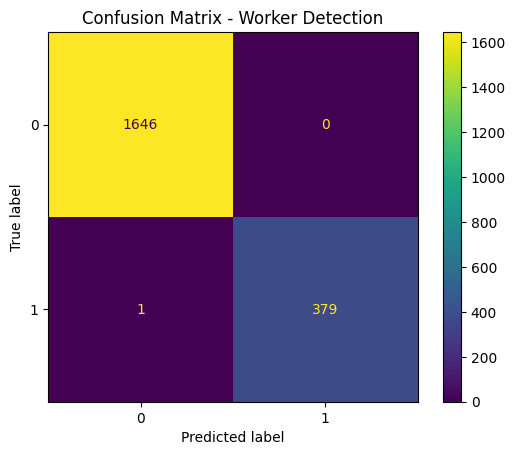

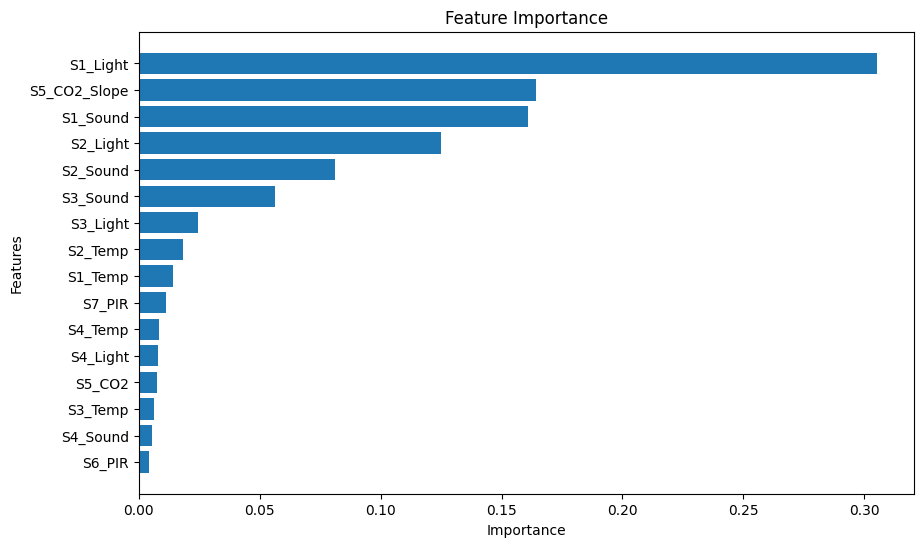

In [189]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay


df["Worker_Present"] = (df["Room_Occupancy_Count"] > 0).astype(int)

feature_cols = [
    "S1_Temp", "S2_Temp", "S3_Temp", "S4_Temp",
    "S1_Light", "S2_Light", "S3_Light", "S4_Light",
    "S1_Sound", "S2_Sound", "S3_Sound", "S4_Sound",
    "S5_CO2", "S5_CO2_Slope",
    "S6_PIR", "S7_PIR"
]

X = df[feature_cols]
y = df["Worker_Present"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix - Worker Detection")
plt.show()

importance = model.feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()


### Key Insights:
- Light sensors (especially S1_Light) have the highest impact on detecting worker presence.
- CO2 slope and sound sensors also contribute significantly to prediction.
- Temperature and PIR sensors have lower influence compared to other features.

This indicates that environmental changes such as light and air quality are strong indicators of human presence.

### Interpretation in Robotics Context:
The robot relies more on light, CO2, and sound sensors to detect human presence, which helps optimize sensor usage in real-world deployment.


This allows the system to focus on the most informative sensors, improving efficiency and reducing unnecessary data processing.

# 5. Time-Based Analysis (Worker Activity Patterns)


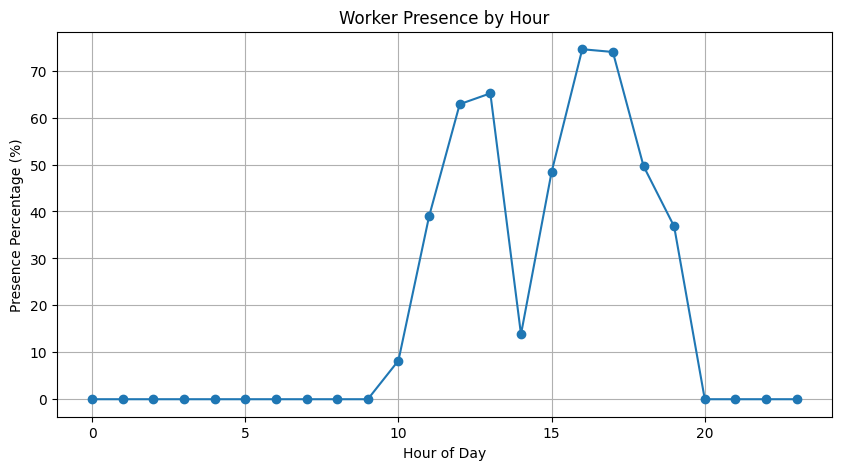

In [205]:
import pandas as pd
import matplotlib.pyplot as plt



df["Hour"] = df.index.hour

df["Worker_Present"] = (df["Room_Occupancy_Count"] > 0).astype(int)

hourly_presence = df.groupby("Hour")["Worker_Present"].mean()

hourly_presence_percent = hourly_presence * 100

plt.figure(figsize=(10,5))
plt.plot(hourly_presence_percent.index, hourly_presence_percent.values, marker='o')
plt.title("Worker Presence by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Presence Percentage (%)")
plt.grid()
plt.show()
anomaly_by_hour = df[df['Anomaly_Label']==-1].groupby('Hour').size()
normal_by_hour = df[df['Anomaly_Label']==1].groupby('Hour').size()




# 6. Cognitive Decision-Making (Thinking Layer)


In [199]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, IsolationForest

worker_detector = model
anomaly_detector = anomaly_model

worker_features = [
    "S1_Temp", "S2_Temp", "S3_Temp", "S4_Temp",
    "S1_Light", "S2_Light", "S3_Light", "S4_Light",
    "S1_Sound", "S2_Sound", "S3_Sound", "S4_Sound",
    "S5_CO2", "S5_CO2_Slope",
    "S6_PIR", "S7_PIR"
]

anomaly_features = [
    "S1_Temp", "S2_Temp", "S3_Temp", "S4_Temp", "Avg_Temp", "Temp_Rate_of_Change",
    "S1_Light", "S2_Light", "S3_Light", "S4_Light",
    "S1_Sound", "S2_Sound", "S3_Sound", "S4_Sound",
    "S5_CO2", "S5_CO2_Slope", "CO2_Rate_of_Change",
    "S6_PIR", "S7_PIR", "Is_Working_Hour"
]

def robot_decision_engine(sensor_reading_raw):
    human_detected = worker_detector.predict(sensor_reading_raw[worker_features])[0]
    sensor_reading_scaled = scaler.transform(sensor_reading_raw[anomaly_features])
    environment_status = anomaly_detector.predict(sensor_reading_scaled)[0]
    
    print(f"\n[Robot Status]: Analyzing live sensor data...")
    
    current_hour = sensor_reading_raw['Hour'].iloc[0] if 'Hour' in sensor_reading_raw.columns else 12
    
    if human_detected == 1 and environment_status == -1:
        action = "Emergency alert: evacuate the storage room immediately and adjust ventilation systems."
    elif human_detected == 1 and environment_status == 1:
        if 8 <= current_hour <= 17:
            action = "Worker detected: adjust lighting and temperature for human presence during official working hours."
        else:
            action = "Security alert: human movement detected outside official working hours."
    elif human_detected == 0 and environment_status == -1:
        action = "Quality alert: environmental change detected that may affect meat; inspect cooling and insulation systems."
    else:
        action = "Safe status: continue the routine data-collection patrol."
        
    print(f"[Robot Decision]: {action}")

sample_data = df[anomaly_features + ['Hour']].iloc[[10]]
robot_decision_engine(sample_data)



[Robot Status]: Analyzing live sensor data...
[Robot Decision]: Worker detected: adjust lighting and temperature for human presence during official working hours.
